<a href="https://colab.research.google.com/github/allvaret/embeddings_similarity_recommendation/blob/main/notebooks/02_recomendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Product recomendation using embeddings
## Dataset & System Overview

The dataset contains 520 product images across 4 categories — sneakers, pants, watches, and t-shirts (~130 images each). Image embeddings were generated using SigLIP2 (google/siglip2-base-patch16-224), a vision-language model that encodes visual semantics into 768-dimensional vectors. Similarity search is performed via FAISS (IndexFlatIP), which computes inner product over normalized embeddings(equivalent to cosine similarity).

## How the Recommendation Works

Each round displays 10 products: on the first round, at least 2 from each category are shown. From the second round onward, 5 products are retrieved by similarity to the user's preference embedding (the running average of all selected item embeddings), and 5 are sampled randomly, thereby ensures at least 1 per category. Images already shown are never repeated.

### Worst-Case Analysis

With 520 images and 10 per round, the showcase runs for at most 52 rounds before exhausting the dataset.

If the user clicks on a sneaker: The preference embedding converges toward the sneaker space. From round 2 onward, all 5 recommended slots are likely to contain sneakers, plus at least 1 from the random slot — yielding ~6 sneakers per round. After the first round (2 guaranteed), a specific sneaker model would appear within at most 22 rounds in the worst case: 2 + (n × 6) ≥ 130 → n = 22.

If the user never clicks on a sneaker: The system receives no signal for that category. Only the random slot guarantees exposure — at least 1 sneaker per round after round 1. In this case, a specific sneaker model could take up to 129 rounds to appear, well beyond the 52-round dataset limit — meaning it may never be shown.

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import torch
# Call the function to start dataset processing
# Ensure the desired directory exists and contains subfolders with images.
dataset_path = "/content/drive/MyDrive/Projects/similarity_recommendation/dataset/"

# Set GPU as processing device, if available
device = "cuda" if torch.cuda.is_available() else "cpu"

In [25]:
def return_sources(category)-> str:
  match category:
    case "sneakers":
      return "https://www.kaggle.com/datasets/nikolasgegenava/sneakers-classification"
    case "tshirts":
      return "https://www.kaggle.com/datasets/sunnykusawa/tshirts"
    case "watches":
      return "https://www.kaggle.com/datasets/mathewkouch/a-dataset-of-watches"
    case "pants":
      return "google_images"

## Create metadata and paths

In [28]:
import os
import csv

def create_metadata_n_path(dataset_path):
  list_paths = []
  if not os.path.exists(dataset_path):
      print(f"Error: Input dataset directory '{dataset_path}' not found.")
      return

  print(f"Starting dataset processing in '{dataset_path}'...")
  csv_filename = "metadata.csv"
  columns = ["id", "model_id", "category", "source", "path"]
  id_i = 0

  with open(csv_filename, "w", newline="", encoding="utf-8") as file:
    writer = csv.DictWriter(file, fieldnames=columns, delimiter=";")

    # Write the first row with column names
    writer.writeheader()

    categories = []
    for root, category_list, filenames in os.walk(dataset_path):

      current_directory_name = os.path.basename(os.path.normpath(root))

      if root == dataset_path:
        categories = category_list
        continue  # Skip to the next iteration, as the root is not a category

      if filenames != 0:
        for filename in filenames:
          if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_path = os.path.join(root, filename)
            print(f"  -> Processing image: {image_path}")
            list_paths.append(image_path)

            # Returns the found category or None if none is found
            category = next((cat for cat in categories if cat in image_path), None)
            # Prepare the entry
            # Inside the try block, populate with information already available such as: id, model_id, category (sneaker) source (kaggle), path
            try:
              row = {
                  "id": id_i,
                  "model_id": current_directory_name,
                  "category": category,
                  "source": return_sources(category),
                  "path": image_path
              }

              writer.writerow(row)
              id_i += 1

            except Exception as e:
              print(f"Error processing image: {image_path} - {e}")

  print(f"File '{csv_filename}' generated successfully!")
  return list_paths

In [17]:
import pandas as pd

list_paths = create_metadata_n_path(dataset_path)

metadata_df = pd.read_csv('/content/metadata.csv',sep=";")
metadata_dict = dict(zip(metadata_df['id'], metadata_df['model_id']))

Starting dataset processing in '/content/drive/MyDrive/Projects/similarity_recommendation/dataset/'...
  -> Processing image: /content/drive/MyDrive/Projects/similarity_recommendation/dataset/sneakers/adidas_forum_high/0096.jpg
    ✓ ID: 0 | Model: adidas_forum_high
  -> Processing image: /content/drive/MyDrive/Projects/similarity_recommendation/dataset/sneakers/adidas_forum_high/0019.jpg
    ✓ ID: 1 | Model: adidas_forum_high
  -> Processing image: /content/drive/MyDrive/Projects/similarity_recommendation/dataset/sneakers/adidas_forum_high/0009.jpg
    ✓ ID: 2 | Model: adidas_forum_high
  -> Processing image: /content/drive/MyDrive/Projects/similarity_recommendation/dataset/sneakers/adidas_forum_high/0067.jpg
    ✓ ID: 3 | Model: adidas_forum_high
  -> Processing image: /content/drive/MyDrive/Projects/similarity_recommendation/dataset/sneakers/adidas_forum_high/0046.jpg
    ✓ ID: 4 | Model: adidas_forum_high
  -> Processing image: /content/drive/MyDrive/Projects/similarity_recommendat

## Load Hugging Face Model
Imports the weights, image processor, and sets the model to evaluation mode (does not update weights).

In [18]:
from transformers import AutoModel, AutoProcessor

# Load model and processor
model = AutoModel.from_pretrained(
    "google/siglip2-base-patch16-224",
    device_map="auto",
    attn_implementation="sdpa"
)
processor = AutoProcessor.from_pretrained("google/siglip2-base-patch16-224")

# Set model to eval mode (important!)
model.eval()

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

SiglipModel(
  (text_model): SiglipTextModel(
    (embeddings): SiglipTextEmbeddings(
      (token_embedding): Embedding(256000, 768)
      (position_embedding): Embedding(64, 768)
    )
    (encoder): SiglipEncoder(
      (layers): ModuleList(
        (0-11): 12 x SiglipEncoderLayer(
          (layer_norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (self_attn): SiglipAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): SiglipMLP(
            (activation_fn): GELUTanh()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768,

## Extract dataset embeddings
Embeddings represent 'semantic meaning' for computers, extracted as numerical vectors (ordered list of numbers in a multidimensional space). We can use them to calculate mathematical relationships and similarities between data.

Original notebook has 4 categories.

In [19]:
from PIL import Image

def process_images_in_batches(image_paths, model, processor, batch_size=32):
    """Processes images in batches, converting all to RGB."""
    all_embeddings = []

    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i:i + batch_size]

        # Load AND convert to RGB
        batch_images = []
        for path in batch_paths:
            img = Image.open(path)
            # Convert to RGB (removes alpha, converts grayscale, etc.)
            if img.mode != 'RGB':
                img = img.convert('RGB')
            batch_images.append(img)

        # Process batch
        inputs = processor(images=batch_images, padding="max_length", max_length=64,return_tensors="pt").to(model.device)

        with torch.no_grad():
            outputs = model.get_image_features(**inputs)
            embeddings = outputs.pooler_output
            embeddings_normalized = embeddings / embeddings.norm(p=2, dim=-1, keepdim=True)

        # Processes on GPU > unloads to CPU (Prevents OOM)
        all_embeddings.append(embeddings_normalized.cpu())

        print(f"Processed {min(i + batch_size, len(image_paths))}/{len(image_paths)} images")

    return torch.cat(all_embeddings, dim=0)

# Usage
embeddings = process_images_in_batches(list_paths, model, processor, batch_size=32)

Processed 32/519 images
Processed 64/519 images
Processed 96/519 images
Processed 128/519 images
Processed 160/519 images
Processed 192/519 images
Processed 224/519 images
Processed 256/519 images
Processed 288/519 images
Processed 320/519 images
Processed 352/519 images
Processed 384/519 images
Processed 416/519 images
Processed 448/519 images
Processed 480/519 images
Processed 512/519 images
Processed 519/519 images


In [20]:
!pip install faiss-gpu
import faiss

##  Interface with gradio and FAISS implementation
It uses Nearest-neighbor search to find a similar embedding.


In [29]:
import gradio as gr
import random
import numpy as np

remaining_indices = None      # indices not yet displayed
preference_embedding = []     # accumulated embedding of choices
# Evaluation state
session_log = []  # list of dicts per iteration
iteration = 0

# Quick mapping: idx → category
idx_to_category = dict(zip(metadata_df['id'], metadata_df['category']))

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def get_random_images_balanced(indices_pool, num, min_per_category=1):
    """
    Returns `num` random indices from the pool, ensuring min_per_category per category.
    Removes selected ones from the pool.

    Returns:
        selected: list of selected indices
        remaining: list of remaining indices
    """
    # Separate pool by category
    by_category = {}
    for idx in indices_pool:
        cat = idx_to_category[idx]
        by_category.setdefault(cat, []).append(idx)

    selected = []

    # Ensure minimum per category
    for cat, idxs in by_category.items():
        sampled = random.sample(idxs, min(min_per_category, len(idxs)))
        selected.extend(sampled)

    # Complete up to `num`
    remaining_pool = [i for i in indices_pool if i not in set(selected)]
    extra_needed = num - len(selected)
    if extra_needed > 0:
        extra = random.sample(remaining_pool, min(extra_needed, len(remaining_pool)))
        selected.extend(extra)

    selected = selected[:num]
    remaining = [i for i in indices_pool if i not in set(selected)]

    return selected, remaining

def find_similar_images(indices_pool, num, pref_embedding):
    """
    Searches for `num` similar to pref_embedding within indices_pool.
    Removes selected ones from the pool.

    Returns:
        similar_indices: list of similar indices
        remaining: list of remaining indices
    """
    # Subset of available embeddings
    pool_array = np.array(indices_pool)
    pool_embeddings = embeddings[pool_array].cpu().numpy().astype('float32')

    # Temporary FAISS index with only the current pool
    temp_index = faiss.IndexFlatIP(pool_embeddings.shape[1])
    temp_index.add(pool_embeddings)

    # Search
    query = np.array(pref_embedding, dtype='float32').reshape(1, -1)
    _, local_indices = temp_index.search(query, k=num)

    # Convert local indices (in pool) to global indices (in dataset)
    similar_global = [pool_array[i] for i in local_indices[0]]

    remaining = [i for i in indices_pool if i not in set(similar_global)]

    return similar_global, remaining

def average_embedding(emb1, emb2):
    """Average of two embeddings."""
    return (np.array(emb1) + np.array(emb2)) / 2

# ============================================================
# GRADIO FUNCTIONS
# ============================================================

def load_images():
    """Initializes showcase with balanced images."""
    global remaining_indices, preference_embedding
    global session_log, iteration
    session_log = []
    iteration = 0

    # Reset state
    preference_embedding = []
    remaining_indices = list(range(len(embeddings)))

    # First iteration: minimum 2 of each category
    selected, remaining_indices = get_random_images_balanced(
        remaining_indices, num=10, min_per_category=2
    )

    # Assemble result: (PIL Image, caption with idx)
    result = [(Image.open(list_paths[idx]).convert('RGB'), str(idx))
              for idx in selected]

    return result

def select_image(evt: gr.SelectData, product_gallery, preference_gallery):
    """User clicked on an image."""
    global remaining_indices, preference_embedding

    # Global index of the selected image (caption = str(idx))
    selected_idx = int(evt.value['caption'])
    selected_emb = embeddings[selected_idx].cpu().numpy()
    selected_img = Image.open(list_paths[selected_idx]).convert('RGB')

    # Update preference (accumulated average)
    if len(preference_embedding) == 0:
        preference_embedding = selected_emb
    else:
        preference_embedding = average_embedding(preference_embedding, selected_emb)

    # 5 similar to preference
    similar_indices, remaining_indices = find_similar_images(
        remaining_indices, num=5, pref_embedding=preference_embedding
    )

    similar_result = [(Image.open(list_paths[idx]).convert('RGB'), str(idx))
                      for idx in similar_indices]

    # 5 random, balanced by category
    random_selected, remaining_indices = get_random_images_balanced(
        remaining_indices, num=5, min_per_category=1
    )

    random_result = [(Image.open(list_paths[idx]).convert('RGB'), str(idx))
                     for idx in random_selected]

    final_result = similar_result + random_result

    # Update preference gallery
    if preference_gallery is None:
        final_preference_gallery = [selected_img]
    else:
        final_preference_gallery = [selected_img] + preference_gallery

    # Metric collection
    global session_log, iteration
    iteration += 1

    # Clicked category
    clicked_category = idx_to_category[selected_idx]

    # Precision@5 of recommendations: how many are from the same category as the click
    precision_5 = sum(
        1 for idx in similar_indices
        if idx_to_category[idx] == clicked_category
    ) / 5

    session_log.append({
        'iteration': iteration,
        'clicked_category': clicked_category,
        'precision_at_5': precision_5,
    })

    print(f"[Iter {iteration}] Clicked: {clicked_category} | Precision@5: {precision_5:.2f}")


    # Embedding debug (if you want)
    # print(f"\n--- Current preference ---")
    # print(f"Shape: {np.array(preference_embedding).shape}")
    # print(f"Norm: {np.linalg.norm(preference_embedding):.4f}")  # should be ~1.0 if normalized
    # print(f"Mean: {np.mean(preference_embedding):.4f}")
    # print(f"Std: {np.std(preference_embedding):.4f}")
    # print(f"Min: {np.min(preference_embedding):.4f} | Max: {np.max(preference_embedding):.4f}")

    return gr.Gallery(value=final_result, selected_index=None), final_preference_gallery

# ============================================================
# INTERFACE
# ============================================================

with gr.Blocks() as demo:
    gr.Markdown("""
    <center><h1>Product Recommendation using Image Similarity</h1></center>
    <center>Dataset: sneakers · pants · watches · tshirts</center>
    <br>
    The user selects their favorite product, which gets added to the preference group.<br>
    Each round: 5 similar to preference embedding + 5 random products.
    """)

    product_gallery = gr.Gallery(
        columns=5,
        object_fit='contain',
        allow_preview=False,
        label='Products'
    )

    preference_gallery = gr.Gallery(
        columns=5,
        object_fit='contain',
        allow_preview=False,
        label='Preference',
        interactive=False
    )

    demo.load(load_images, inputs=None, outputs=[product_gallery])

    product_gallery.select(
        select_image,
        inputs=[product_gallery, preference_gallery],
        outputs=[product_gallery, preference_gallery]
    )
demo.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://c2ddf75ba91b9e53a9.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


[Iter 1] Clicked: sneakers | Precision@5: 1.00
[Iter 2] Clicked: sneakers | Precision@5: 1.00
[Iter 3] Clicked: pants | Precision@5: 1.00
[Iter 4] Clicked: tshirts | Precision@5: 1.00
[Iter 5] Clicked: watches | Precision@5: 1.00
[Iter 6] Clicked: watches | Precision@5: 1.00
[Iter 7] Clicked: tshirts | Precision@5: 1.00
[Iter 8] Clicked: pants | Precision@5: 1.00
[Iter 9] Clicked: pants | Precision@5: 1.00
[Iter 10] Clicked: watches | Precision@5: 1.00
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://2deb238a409ede2678.gradio.live
Killing tunnel 127.0.0.1:7861 <> https://c2ddf75ba91b9e53a9.gradio.live


# Evaluation


## Reading the Evaluation Plot
- The Precision@5 curve measures, at each click, how many of the 5 recommended products belong to the same category as the item the user just selected.  
- A rising curve indicates the system is learning the user's preference correctly.  
- A flat or noisy curve suggests mixed preferences or slow convergence.  
- The 3-point moving average smooths iteration-level noise to reveal the underlying trend.  
- The bar chart below shows the distribution of clicks across categories for the full session.



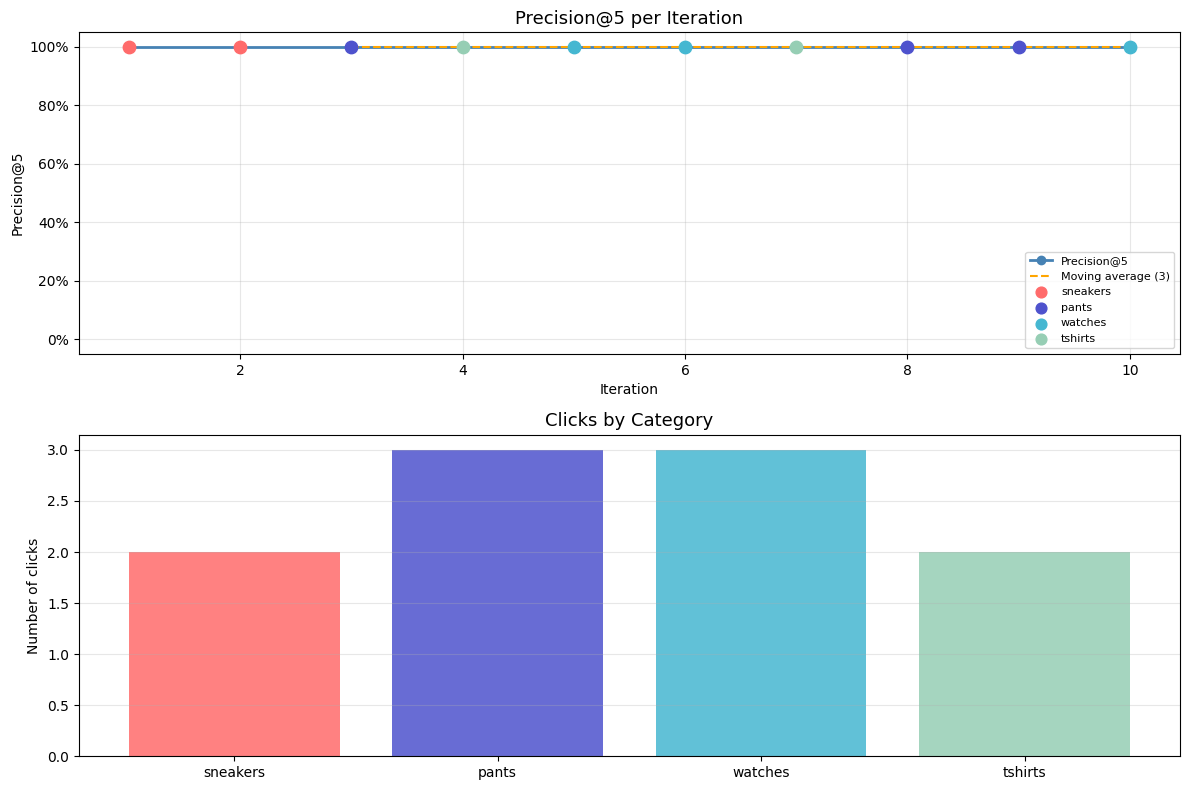


--- Session Summary ---
Total iterations: 10
Average Precision@5: 1.00
Final Precision@5: 1.00
Most clicked category: pants


In [30]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

def plot_session_evaluation(session_log):
    if not session_log:
        print("No session recorded.")
        return

    iterations = [entry['iteration'] for entry in session_log]
    precisions = [entry['precision_at_5'] for entry in session_log]
    categories = [entry['clicked_category'] for entry in session_log]

    # Colors by category
    color_map = {
        'sneakers': '#FF6B6B',
        'pants':    '#4e52cd',
        'watches':  '#45B7D1',
        'tshirts':  '#96CEB4'
    }
    colors = [color_map.get(cat, '#888') for cat in categories]

    fig, axes = plt.subplots(2, 1, figsize=(12, 8))

    # --- Plot 1: Precision@5 per iteration ---
    axes[0].plot(iterations, precisions, color='steelblue',
                 linewidth=2, marker='o', markersize=6, label='Precision@5')

    # Color points by clicked category
    for i, (x, y, c) in enumerate(zip(iterations, precisions, colors)):
        axes[0].scatter(x, y, color=c, zorder=5, s=80)

    # Moving average line (window 3)
    if len(precisions) >= 3:
        moving_avg = np.convolve(precisions, np.ones(3)/3, mode='valid')
        axes[0].plot(iterations[2:], moving_avg, '--', color='orange',
                    linewidth=1.5, label='Moving average (3)')

    axes[0].set_title('Precision@5 per Iteration', fontsize=13)
    axes[0].set_xlabel('Iteration')
    axes[0].set_ylabel('Precision@5')
    axes[0].set_ylim(-0.05, 1.05)
    axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Category legend (colored points)
    for cat, color in color_map.items():
        axes[0].scatter([], [], color=color, label=cat, s=60)
    axes[0].legend(loc='lower right', fontsize=8)

    # --- Plot 2: Click distribution by category ---
    cat_counts = {cat: categories.count(cat) for cat in color_map.keys()}
    axes[1].bar(cat_counts.keys(), cat_counts.values(),
                color=[color_map[c] for c in cat_counts.keys()], alpha=0.85)
    axes[1].set_title('Clicks by Category', fontsize=13)
    axes[1].set_ylabel('Number of clicks')
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Summary
    print(f"\n--- Session Summary ---")
    print(f"Total iterations: {len(session_log)}")
    print(f"Average Precision@5: {np.mean(precisions):.2f}")
    print(f"Final Precision@5: {precisions[-1]:.2f}")
    print(f"Most clicked category: {max(cat_counts, key=cat_counts.get)}")

# Run after the showcase session:
plot_session_evaluation(session_log)